**Scikit-learn Kütüphanesi ve Makine Öğrenmesi Veri Mimarisi**

Makine öğrenmesi süreçlerinde verinin doğru yapılandırılması, modelin başarısı için ön koşuldur. Python ekosisteminde bu sürecin standartlarını belirleyen Scikit-learn, veriyi iki temel bileşen üzerinden yönetir: Öznitelik Matrisi ve Hedef Değişken.

**1. Temel Kavramlar ve Veri Yapısı**

Literatürde her bir gözlem birimi (satır) örneklem (sample), bu örneklemi tanımlayan her bir değişken (sütun) ise öznitelik (feature) olarak adlandırılır. İstatistiksel bağlamda öznitelikler "bağımsız değişkenler" olarak tanımlanır.

**Öznitelik Matrisi (X):** Veri setindeki açıklayıcı değişkenleri içeren iki boyutlu yapıdır. Genellikle [$n_{samples}$, $n_{features}$] boyutunda bir matris formundadır.

**Hedef Dizisi (y):** Her bir örnekleme karşılık gelen ve tahmin edilmesi beklenen sonuç değerlerini içeren tek boyutlu yapıdır (etiket/label).

**2. Uygulama: Iris Veri Setinin Yüklenmesi**

Veri biliminin klasikleşmiş örneği olan Iris (Zambak) veri seti, görselleştirme ve istatistiksel kütüphaneler (örneğin seaborn) üzerinden kolaylıkla temin edilebilir:

In [ ]:
import seaborn as sns

# Veri setinin yüklenmesi
iris = sns.load_dataset('iris')

# Veri yapısının ilk 5 satırının incelenmesi
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


**3. Scikit-learn API'sinin Temel Özellikleri**

Scikit-learn, "Estimator" (Tahminci) tasarımı sayesinde tüm algoritmalar için tutarlı bir kullanım arayüzü sunar. Bu kütüphanenin öne çıkan metodolojileri şunlardır:

**Tutarlılık: **Tüm nesneler (modeller) ortak bir arayüzü paylaşır (fit, predict, transform).

**Denetimli Öğrenme (Supervised Learning):** Girdi (X) ve çıktı (y) arasındaki ilişkinin öğrenildiği yöntemlerdir (Sınıflandırma ve Regresyon).

**Denetimsiz Öğrenme (Unsupervised Learning):** Sadece girdi (X) üzerinden verideki gizli yapıların (kümeleme gibi) saptandığı yöntemlerdir.


Makine öğrenmesi modelinin inşası, özünde bir fonksiyon kestirimi sürecidir. Scikit-learn bizlere, y=f(X) denklemini en düşük hata payıyla çözecek algoritmik araçları standartlaştırılmış bir yapıda sunar. Öznitelik matrisinin boyutları ve hedef dizisinin tipi (sayısal veya kategorik), uygulanacak algoritmanın seçimine doğrudan yön verir

**Veri Yapılarının Ayrıştırılması: Öznitelik Matrisi ve Hedef Vektörü Operasyonları**

Makine öğrenmesi modellerinin eğitim aşamasına geçmeden önce, ham veri setinin algoritma tarafından işlenebilecek iki temel bileşene—Öznitelik Matrisi (X) ve Hedef Vektörü (y)—ayrıştırılması gerekmektedir. Bu süreçte izlenen metodoloji şöyledir:

**1. Öznitelik Matrisinin (X) Yapılandırılması**

Analiz sürecinde "bağımsız değişkenler" kümesini oluşturmak amacıyla, hedef sınıfı temsil eden sütun veri setinden dışlanır. Pandas kütüphanesindeki drop metodu kullanılarak gerçekleştirilen bu işlemde, sütun bazlı bir operasyon yapıldığını belirtmek için axis=1 parametresi kullanılır.

In [ ]:
# 'species' sütunu dışlanarak öznitelik matrisinin oluşturulması
X_iris = iris.drop('species', axis=1)

# Matris boyutlarının kontrolü
print(f"Öznitelik Matrisi Boyutu: {X_iris.shape}")
# Çıktı: (150, 4) -> 150 örneklem ve 4 açıklayıcı değişken

Öznitelik Matrisi Boyutu: (150, 4)


**2. Hedef Vektörünün (y) Tanımlanması**

Tahmin edilmesi hedeflenen "bağımlı değişken", veri setinden izole edilerek genellikle y sembolü ile gösterilen tek boyutlu bir vektöre atanır.

In [ ]:
# Hedef değişkenin (etiketlerin) ayrıştırılması
y_iris = iris['species']

# Vektör boyutunun kontrolü
print(f"Hedef Vektörü Boyutu: {y_iris.shape}")
# Çıktı: (150,) -> Her bir örneklem için bir sınıf etiketi

Hedef Vektörü Boyutu: (150,)


**3. Scikit-Learn ile Model İnşa Süreci (Adım Adım)**

Veri yapıları hazırlandıktan sonra, Scikit-learn kütüphanesinin standartlaştırılmış iş akışı şu dört temel adım üzerinden yürütülür:

**Model Seçimi ve Sınıfın İçe Aktarılması:** Problem tipine (sınıflandırma veya regresyon) uygun algoritma sınıfı kütüphaneden çağrılır.

**Hiperparametre Yapılandırması (Model Örneklendirme):**

Model sınıfından bir nesne üretilirken, algoritmanın davranışını belirleyen hiperparametreler (örneğin k-NN için n_neighbors) tanımlanır.

**Model Eğitimi (Fitting):** fit(X, y) metodu kullanılarak, modelin öznitelikler ile hedef değişken arasındaki matematiksel ilişkiyi öğrenmesi sağlanır.

**Tahmin Üretme (Prediction):** Eğitilen model, predict() metodu aracılığıyla daha önce karşılaşmadığı yeni veri noktaları üzerinde çıkarımlarda bulunur.

**Makine Öğrenmesi İş Akışı ve Uygulamalı Metodoloji**

Makine öğrenmesi, verinin matematiksel bir temsilinden (model) hareketle, yeni ve görülmemiş veriler üzerinde çıkarım yapma sürecidir.

**1. Basit Doğrusal Regresyon (Simple Linear Regression)**

Doğrusal regresyon, bağımlı ve bağımsız değişkenler arasındaki ilişkiyi bir doğru denklemiyle modellemeyi hedefler.

Eğim (Slope): [1.9776566]
Kesim Noktası (Intercept): -0.9033107255311146


Text(0.5, 1.0, 'Basit Doğrusal Regresyon Uygulaması')

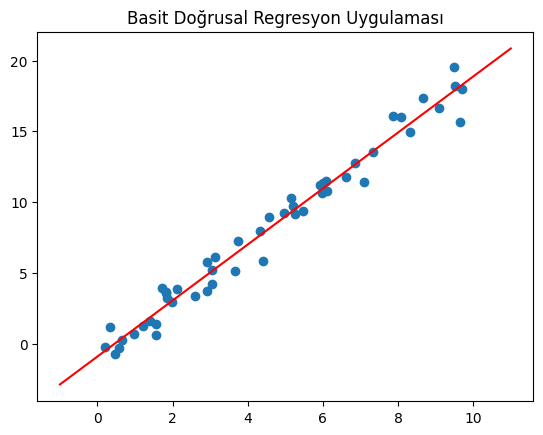

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Veri Simülasyonu
rng = np.random.RandomState(42)
X = 10 * rng.rand(50)
y = 2 * X - 1 + rng.randn(50)

# 2. Öznitelik Matrisini Düzenleme (Reshaping)
# Scikit-learn X matrisinin iki boyutlu olmasını bekler.
X_matrix = X[:, np.newaxis]

# 3. Modelin Yapılandırılması ve Eğitimi
model = LinearRegression(fit_intercept=True)
model.fit(X_matrix, y)

# 4. Katsayıların İncelenmesi
print(f"Eğim (Slope): {model.coef_}")
print(f"Kesim Noktası (Intercept): {model.intercept_}")

# 5. Görselleştirme
X_fit = np.linspace(-1, 11, 50)[:, np.newaxis]
y_fit = model.predict(X_fit)

plt.scatter(X, y)
plt.plot(X_fit, y_fit, color='red')
plt.title("Basit Doğrusal Regresyon Uygulaması")

\**2. Denetimli Öğrenme: Sınıflandırma (GNB) Gaussian Naive Bayes**

Iris veri seti üzerinde, çiçeklerin özelliklerine bakarak türlerini tahmin etmek için olasılıksal bir yaklaşım olan Gaussian Naive Bayes kullanılır.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Veriyi Bölümleme (Train-Test Split)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_iris, y_iris, random_state=1)

# 2. Model Seçimi ve Eğitimi
model_gnb = GaussianNB()
model_gnb.fit(X_egitim, y_egitim)

# 3. Tahmin ve Performans Değerlendirme
y_tahmin = model_gnb.predict(X_test)
print(f"Model Doğruluk Oranı: {accuracy_score(y_test, y_tahmin):.2f}")

Model Doğruluk Oranı: 0.97


**3. Denetimsiz Öğrenme: Boyut İndirgeme ve Kümeleme**

Veride hedef etiketler (labels) olmadan, verinin kendi iç yapısını keşfetmek için kullanılır.

**A. PCA ile Boyut İndirgeme (Dimensionality Reduction)**

4 boyutlu Iris verisini görselleştirebilmek için 2 boyuta indirgeriz:

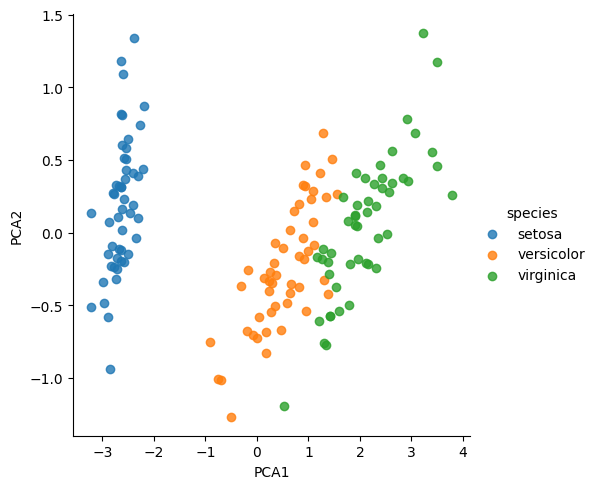

In [ ]:
from sklearn.decomposition import PCA

# 1. Model Örneklendirme (2 bileşen hedefliyoruz)
model_pca = PCA(n_components=2)
X_2D = model_pca.fit_transform(X_iris)

# 2. Sonuçların Veri Setine Eklenmesi ve Görselleştirme
import seaborn as sns
iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]
sns.lmplot(x="PCA1", y="PCA2", hue='species', data=iris, fit_reg=False)

**B. GMM (Gaussian Mixture Model) ile Kümeleme (Clustering)**

Algoritmanın, tür isimlerini bilmeden çiçekleri gruplandırmasını sağlar:

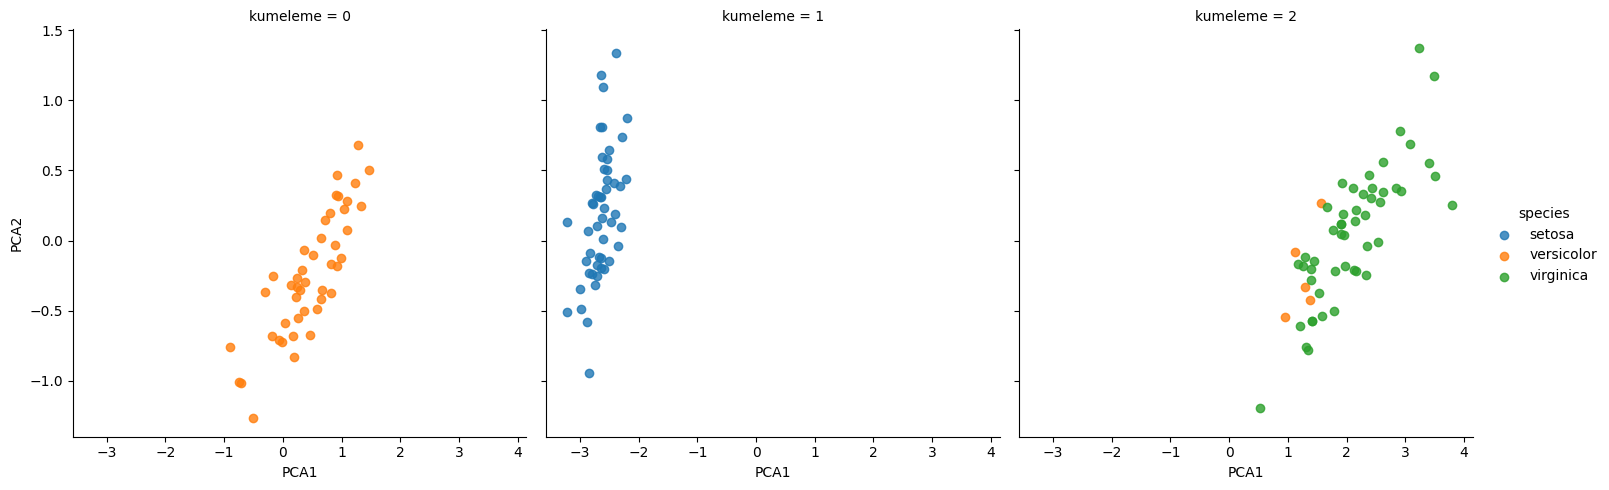

In [ ]:
from sklearn.mixture import GaussianMixture

# 1. Kümeleme Modelinin Kurulması
model_gmm = GaussianMixture(n_components=3)
model_gmm.fit(X_iris)

# 2. Küme Etiketlerinin Tahmin Edilmesi
y_gmm = model_gmm.predict(X_iris)
iris['kumeleme'] = y_gmm

# Görselleştirme
sns.lmplot(x="PCA1", y="PCA2", data=iris, hue='species', col='kumeleme', fit_reg=False)

**4. Karmaşıklık Matrisi (Confusion Matrix) ile Hata Analizi**

Özellikle rakam tanıma (Digits) gibi çok sınıflı problemlerde modelin başarısını detaylandırmak için kullanılır:

Text(50.722222222222214, 0.5, 'Gerçek Değer')

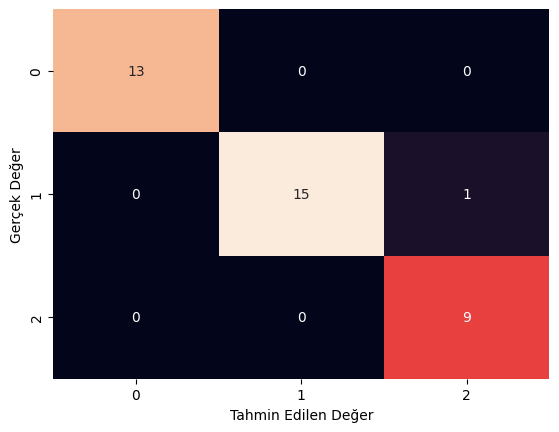

In [ ]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test, y_tahmin)
sns.heatmap(mat, annot=True, cbar=False)
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Gerçek Değer')

**Akademik Özet:**

Bu iş akışı, verinin ham halinden alınarak anlamlı istatistiksel çıkarımlara dönüştürülmesini sağlar. fit() metodolojisiyle öğrenen modeller, predict() ile yeni senaryolara uyarlanır. Boyut indirgeme yöntemleri veriyi "anlaşılır" kılarken, doğruluk metrikleri ve hata matrisleri kurulan modelin bilimsel geçerliliğini tescil eder.

**Denetimli Öğrenme:** Gaussian Naive Bayes Sınıflandırma Modeli
Makine öğrenmesinde denetimli öğrenme süreci, verinin eğitim ve test olarak ayrılmasıyla başlar. Görselde yer alan iş akışını şu teknik adımlarla gerçekleştirebiliriz:

**1. Veri Setinin Bölümlenmesi (Train-Test Split)**

Modelin genelleme yeteneğini ölçmek için veriyi ikiye ayırıyoruz. Bu aşamada random_state=1 parametresi, çalışmanın tekrarlanabilirliğini sağlar.

In [ ]:
from sklearn.model_selection import train_test_split

# Veriyi %75 eğitim ve %25 test olarak ayırıyoruz
X_egitim, X_test, y_egitim, y_test = train_test_split(X_iris, y_iris, random_state=1)

**2. Model Seçimi ve Yapılandırma**

Sınıflandırma problemi için olasılıksal bir yaklaşım sunan Gaussian Naive Bayes (GNB) algoritmasını tercih ediyoruz. GNB, özniteliklerin normal (Gaussian) dağılıma sahip olduğu varsayımıyla çalışır.

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Model nesnesinin örneklendirilmesi
model = GaussianNB()

3. Model Eğitimi (Fitting)

Bu aşama, algoritmanın öznitelik matrisi $(X_{egitim}$) ile hedef etiketler $(y_{egitim}$) arasındaki istatistiksel ilişkiyi öğrendiği süreçtir.

In [ ]:
# Modelin eğitim verileriyle uyumlandırılması
model.fit(X_egitim, y_egitim)

GaussianNB()

**4. Tahmin ve Performans Değerlendirmesi**

Eğitilen modeli kullanarak test verileri üzerinde tahminler üretiriz ve modelin başarısını Doğruluk Skoru (Accuracy Score) ile ölçeriz.

In [ ]:
from sklearn.metrics import accuracy_score

# Test verisi üzerinden tahmin yapma
y_model = model.predict(X_test)

# Modelin doğruluk oranını hesaplama
dogruluk = accuracy_score(y_test, y_model)
print(f"Modelin Doğruluk Skoru: {dogruluk:.2f}")

Modelin Doğruluk Skoru: 0.97


**Akademik Değerlendirme**

Görseldeki süreç, Scikit-learn kütüphanesinin "Estimator API" mimarisini temsil eder. `fit()` metodu ile gerçekleşen öğrenme süreci, `predict()` metodu ile çıkarıma dönüşür. Elde edilecek olan yüksek doğruluk skoru, Gaussian Naive Bayes algoritmasının Iris gibi düşük boyutlu ve sınıfları belirgin veri setlerinde ne kadar efektif çalıştığının bir göstergesidir.